In [1]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()

X = data.data 
y = data.target 

In [2]:
print(X.shape)
print(y.shape)
print(data.target_names)

(569, 30)
(569,)
['malignant' 'benign']


In [3]:
from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split(X , y , random_state = 42 , test_size = 0.2 , stratify = y)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


(455, 30)
(114, 30)
(455,)
(114,)


In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors = 1)

knn.fit(X_train_scaled , y_train)

y_pred = knn.predict(X_test_scaled)

In [6]:
from sklearn.metrics import accuracy_score 

accuracy = accuracy_score(y_test , y_pred)

print("K = 1")
print('Accuracy :' , accuracy)

K = 1
Accuracy : 0.9385964912280702


In [7]:
knn = KNeighborsClassifier(n_neighbors = 3 )

knn.fit(X_train_scaled , y_train)

y_pred = knn.predict(X_test_scaled)

accuracy = accuracy_score(y_test , y_pred)

print('k = 3')
print("Accuracy :" , accuracy)

k = 3
Accuracy : 0.9824561403508771


In [8]:
knn = KNeighborsClassifier(n_neighbors = 5 )

knn.fit(X_train_scaled , y_train)

y_pred = knn.predict(X_test_scaled)

accuracy = accuracy_score(y_test , y_pred)

print('k = 5')
print("Accuracy :" , accuracy)

k = 5
Accuracy : 0.956140350877193


In [9]:
knn = KNeighborsClassifier(n_neighbors = 7 )

knn.fit(X_train_scaled , y_train)

y_pred = knn.predict(X_test_scaled)

accuracy = accuracy_score(y_test , y_pred)

print('k = 7')
print("Accuracy :" , accuracy)

k = 7
Accuracy : 0.9736842105263158


In [10]:
knn = KNeighborsClassifier(n_neighbors = 9 )

knn.fit(X_train_scaled , y_train)

y_pred = knn.predict(X_test_scaled)

accuracy = accuracy_score(y_test , y_pred)

print('k = 9')
print("Accuracy :" , accuracy)

k = 9
Accuracy : 0.9736842105263158


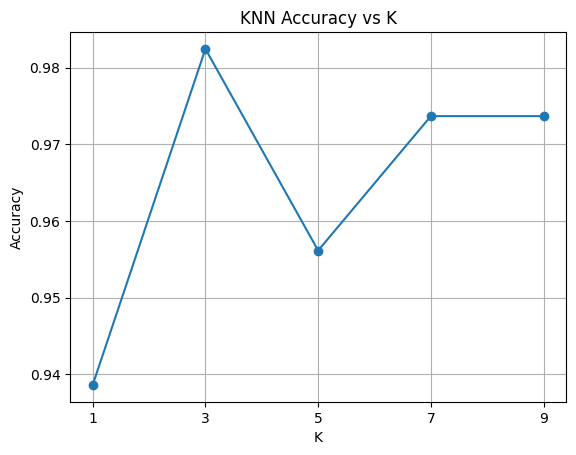

In [11]:
import matplotlib.pyplot as plt

k_values = [1,3,5,7,9]
accuracies = [0.9385964912280702,
    0.9824561403508771,
    0.956140350877193,
    0.9736842105263158,
    0.9736842105263158]
plt.plot(k_values , accuracies , marker = 'o')

plt.xlabel('K')
plt.ylabel('Accuracy')
plt.title('KNN Accuracy vs K')

plt.xticks(k_values)
plt.grid()

plt.show()

In [13]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train_scaled , y_train)

y_pred_nb = nb.predict(X_test_scaled)
accuracy_nb = accuracy_score(y_test , y_pred_nb)
print("Naive Bayes Accuracy : " , accuracy_nb)

Naive Bayes Accuracy :  0.9298245614035088


In [14]:
from sklearn.metrics import precision_score , f1_score , recall_score

precision = precision_score(y_test , y_pred_nb)
recall = recall_score(y_test , y_pred_nb)
f1 = f1_score(y_test , y_pred_nb)

print("Precision Score :" , precision)
print("Recall Score :" , recall)
print("f1 Score :" , f1)

Precision Score : 0.9444444444444444
Recall Score : 0.9444444444444444
f1 Score : 0.9444444444444444


In [15]:
from sklearn.metrics import roc_auc_score

y_prob_nb = nb.predict_proba(X_test_scaled)[: , 1]

roc_auc = roc_auc_score(y_test , y_prob_nb)
print("Roc_Auc :" , roc_auc )

Roc_Auc : 0.9867724867724867


In [16]:
from sklearn.metrics import classification_report

print(classification_report(y_test , y_pred_nb))

              precision    recall  f1-score   support

           0       0.90      0.90      0.90        42
           1       0.94      0.94      0.94        72

    accuracy                           0.93       114
   macro avg       0.92      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114



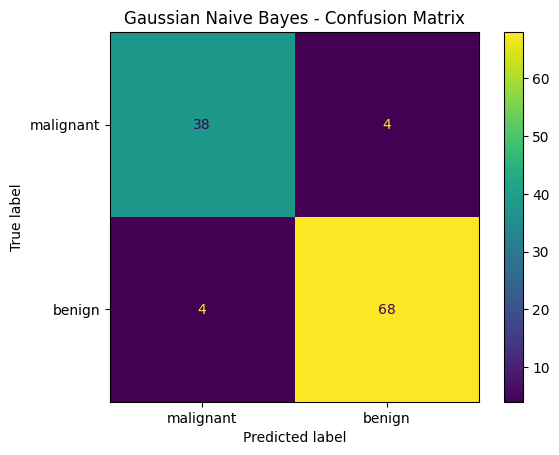

In [18]:
from sklearn.metrics import confusion_matrix , ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test , y_pred_nb)

disp = ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels = data.target_names
)

disp.plot()

plt.title("Gaussian Naive Bayes - Confusion Matrix")
plt.show()

In [20]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Create KNN with best K
knn_best = KNeighborsClassifier(n_neighbors=3)

# Train
knn_best.fit(X_train_scaled, y_train)

# Predictions
y_pred_knn = knn_best.predict(X_test_scaled)

# Probabilities
y_prob_knn = knn_best.predict_proba(X_test_scaled)[:, 1]

# Evaluation
knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_precision = precision_score(y_test, y_pred_knn)
knn_recall = recall_score(y_test, y_pred_knn)
knn_f1 = f1_score(y_test, y_pred_knn)
knn_roc_auc = roc_auc_score(y_test, y_prob_knn)

print("KNN Accuracy :", knn_accuracy)
print("KNN Precision:", knn_precision)
print("KNN Recall   :", knn_recall)
print("KNN F1 Score :", knn_f1)
print("KNN ROC-AUC  :", knn_roc_auc)

KNN Accuracy : 0.9824561403508771
KNN Precision: 0.972972972972973
KNN Recall   : 1.0
KNN F1 Score : 0.9863013698630136
KNN ROC-AUC  : 0.9834656084656085


In [21]:
from sklearn.metrics import classification_report

print(classification_report(y_test , y_pred_knn))

              precision    recall  f1-score   support

           0       1.00      0.95      0.98        42
           1       0.97      1.00      0.99        72

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [23]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test , y_pred_knn)

print("Confusion Matrix Knn :" , cm)

Confusion Matrix Knn : [[40  2]
 [ 0 72]]


In [28]:
import pandas as pd
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()

df = pd.DataFrame(data.data , columns = data.feature_names)
df['target'] = data.target
X = df.drop(columns=['target'])
y = df['target']
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [33]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(X , y , random_state = 42 , test_size = 0.2) 
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(455, 30)
(455,)
(114, 30)
(114,)


In [36]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [38]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
for i in [1,3,5,7,9]:
    knn = KNeighborsClassifier(n_neighbors = i)
    knn.fit(X_train_scaled , y_train)
    y_pred_knn = knn.predict(X_test_scaled)
    print(f"K = {i}" )
    print("Accuracy Score : " , accuracy_score(y_test , y_pred_knn))

K = 1
Accuracy Score :  0.9385964912280702
K = 3
Accuracy Score :  0.9473684210526315
K = 5
Accuracy Score :  0.9473684210526315
K = 7
Accuracy Score :  0.9473684210526315
K = 9
Accuracy Score :  0.9649122807017544


In [41]:
knn_scaled = KNeighborsClassifier(n_neighbors = 5)
knn_unscaled = KNeighborsClassifier(n_neighbors = 5)

knn_unscaled.fit(X_train , y_train)
y_pred_unscaled = knn_unscaled.predict(X_test)
knn_scaled.fit(X_train_scaled , y_train)
y_pred_scaled = knn_scaled.predict(X_test_scaled)
print("Accuracy of Scaled :" , accuracy_score(y_test , y_pred_scaled) )
print("Accuracy of UnScaled :" , accuracy_score(y_test , y_pred_unscaled) )

Accuracy of Scaled : 0.9473684210526315
Accuracy of UnScaled : 0.956140350877193


In [85]:
#Importing the models and metrics and preprocessing scalers 
from sklearn.linear_model import LogisticRegression 
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score , precision_score , recall_score , f1_score , roc_auc_score
from sklearn.preprocessing import StandardScaler
import pandas as pd 

# Scaling
scaler = StandardScaler() 
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


#Defining the Models 
logisticregression = LogisticRegression()
randomforest = RandomForestClassifier(n_estimators = 100 , random_state = 42)
dicisiontree = DecisionTreeClassifier(max_depth = 3 , min_samples_split = 4 , random_state = 42)
knn = KNeighborsClassifier(n_neighbors = 9)
gaussiannb = GaussianNB()

# LogisticRegression
logisticregression.fit(X_train_scaled , y_train)
y_pred_lr = logisticregression.predict(X_test_scaled)
y_prob_lr = logisticregression.predict_proba(X_test_scaled)[: , 1]
accuracy_score_lr = accuracy_score(y_test , y_pred_lr)
precision_score_lr = precision_score(y_test , y_pred_lr)
recall_score_lr = recall_score(y_test , y_pred_lr)
f1_score_lr = f1_score(y_test , y_pred_lr)
roc_auc_score_lr = roc_auc_score(y_test , y_prob_lr)
# print("Accuracy Score for LogisticRegression : " , accuracy_score(y_test , y_pred_lr))
# print("Precision Score for LogisticRegression : " , precision_score(y_test , y_pred_lr))
# print("Recall Score for LogisticRegression : " , recall_score(y_test , y_pred_lr))
# print("F1 Score for LogisticRegression : " , f1_score(y_test , y_pred_lr))
# print("ROC-AUC Score for LogisticRegression : " , roc_auc_score(y_test , y_pred_lr))
# print("\n")

#DecisionTree
dicisiontree.fit(X_train , y_train)
y_pred_dt = dicisiontree.predict(X_test)
y_prob_dt = dicisiontree.predict_proba(X_test)[: , 1]
accuracy_score_dt = accuracy_score(y_test , y_pred_dt)
precision_score_dt = precision_score(y_test , y_pred_dt)
recall_score_dt = recall_score(y_test , y_pred_dt)
f1_score_dt = f1_score(y_test , y_pred_dt)
roc_auc_score_dt = roc_auc_score(y_test , y_prob_dt)
# print("Accuracy Score for DecisionTree : " , accuracy_score(y_test , y_pred_dt))
# print("Precision Score for DecisionTree : " , precision_score(y_test , y_pred_dt))
# print("Recall Score for DecisionTree : " , recall_score(y_test , y_pred_dt))
# print("F1 Score for DecisionTree : " , f1_score(y_test , y_pred_dt))
# print("ROC-AUC Score for DecisionTree : " , roc_auc_score(y_test , y_pred_dt))
# print("\n")

#RandomForest
randomforest.fit(X_train , y_train)
y_pred_rf = randomforest.predict(X_test)
y_prob_rf = randomforest.predict_proba(X_test)[: , 1]
accuracy_score_rf = accuracy_score(y_test , y_pred_rf)
precision_score_rf = precision_score(y_test , y_pred_rf)
recall_score_rf = recall_score(y_test , y_pred_rf)
f1_score_rf = f1_score(y_test , y_pred_rf)
roc_auc_score_rf = roc_auc_score(y_test , y_prob_rf)
# print("Accuracy Score for RandomForest : " , accuracy_score(y_test , y_pred_rf))
# print("Precision Score for RandomForest : " , precision_score(y_test , y_pred_rf))
# print("Recall Score for RandomForest : " , recall_score(y_test , y_pred_rf))
# print("F1 Score for RandomForest : " , f1_score(y_test , y_pred_rf))
# print("ROC-AUC Score for RandomForest : " , roc_auc_score(y_test , y_pred_rf))
# print("\n")

#KNN
knn.fit(X_train_scaled , y_train)
y_pred_knn = knn.predict(X_test_scaled)
y_prob_knn = knn.predict_proba(X_test_scaled)[: , 1]
accuracy_score_knn = accuracy_score(y_test , y_pred_knn)
precision_score_knn = precision_score(y_test , y_pred_knn)
recall_score_knn = recall_score(y_test , y_pred_knn)
f1_score_knn = f1_score(y_test , y_pred_knn)
roc_auc_score_knn = roc_auc_score(y_test , y_prob_knn)
# print("Accuracy Score for KNN : " , accuracy_score(y_test , y_pred_knn))
# print("Precision Score for KNN : " , precision_score(y_test , y_pred_knn))
# print("Recall Score for KNN : " , recall_score(y_test , y_pred_knn))
# print("F1 Score for KNN : " , f1_score(y_test , y_pred_knn))
# print("ROC-AUC Score for KNN : " , roc_auc_score(y_test , y_pred_knn))
# print("\n")

#Gaussian NB
gaussiannb.fit(X_train , y_train)
y_pred_gnb = gaussiannb.predict(X_test)
y_prob_gnb = gaussiannb.predict_proba(X_test)[: , 1]
accuracy_score_gnb = accuracy_score(y_test , y_pred_gnb)
precision_score_gnb = precision_score(y_test , y_pred_gnb)
recall_score_gnb = recall_score(y_test , y_pred_gnb)
f1_score_gnb = f1_score(y_test , y_pred_gnb)
roc_auc_score_gnb = roc_auc_score(y_test , y_prob_gnb)
# print("Accuracy Score for GaussianNB : " , accuracy_score(y_test , y_pred_gnb))
# print("Precision Score for GaussianNB : " , precision_score(y_test , y_pred_gnb))
# print("Recall Score for GaussianNB : " , recall_score(y_test , y_pred_gnb))
# print("F1 Score for GaussianNB : " , f1_score(y_test , y_pred_gnb))
# print("ROC-AUC Score for GaussianNB : " , roc_auc_score(y_test , y_pred_gnb))
# print("\n")

data = {
    "Model" : ["LogisticRegression" , "DecisionTree" , "RandomForest" , "KNeighbors" , 'Gaussian Native Bayes'] , 
    "Accuracy" : [accuracy_score_lr ,accuracy_score_dt ,accuracy_score_rf ,accuracy_score_knn ,accuracy_score_gnb] ,  
    "Precision" : [precision_score_lr ,precision_score_dt ,precision_score_rf ,precision_score_knn ,precision_score_gnb] ,  
    "Recall" : [recall_score_lr ,recall_score_dt ,recall_score_rf ,recall_score_knn ,recall_score_gnb] ,  
    "F1 Score" : [f1_score_lr ,f1_score_dt ,f1_score_rf ,f1_score_knn ,f1_score_gnb] ,  
    "ROC-AUC" : [roc_auc_score_lr ,roc_auc_score_dt ,roc_auc_score_rf ,roc_auc_score_knn ,roc_auc_score_gnb] }

df = pd.DataFrame(data)
df.sort_values(by = "F1 Score" , ascending =False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
4,Gaussian Native Bayes,0.973684,0.959459,1.000000,0.979310,0.998362
0,LogisticRegression,0.973684,0.972222,0.985915,0.979021,0.997380
2,RandomForest,0.964912,0.958904,0.985915,0.972222,0.995251
3,KNeighbors,0.964912,0.971831,0.971831,0.971831,0.980675
1,DecisionTree,0.947368,0.945205,0.971831,0.958333,0.957419


In [88]:
def calculate_avg(numbers):
    avg = sum(numbers) / len(numbers)
    return avg
calculate_avg([10, 20, 30, 40])

25.0

In [91]:
class Student : 
    def __init__(self , name , age , score) :
        self.name = name 
        self.age = age 
        self.score = score 
    def display_info(self):
        print(f"Name : {self.name} \nAge : {self.age} \nScore : {self.score}")
student = Student("Dhruv" , 20 , 94)
student.display_info()

Name : Dhruv 
Age : 20 
Score : 94


In [95]:
import numpy as np 

arr = np.array([10,20,30,40,50])
arr.mean()
np.median(arr)
arr.std()
arr.max()
arr.min()

np.int64(10)

In [103]:
df = pd.DataFrame({"Name" : ['A' , 'B' , 'C' , 'D' ] , 
             "Age" : [20 ,21 ,19 , 22 ],
             "Score" : [85 , 90 , 78, 95]})
df[['Name' , 'Score']]
df[df['Score'] > 85]
df['Score'].mean()
df.sort_values(by = "Score" , ascending = False)

,Name,Age,Score
3,D,22,95
1,B,21,90
0,A,20,85
2,C,19,78


In [114]:
student_scores = {
    "A": 85,
    "B": 90,
    "C": 78,
    "D": 95
}
max(student_scores)
avg = sum(student_scores.values()) / len(student_scores)
for i in student_scores:
    if student_scores[i] > 85 : 
        print(i)

B
D


In [120]:
numbers = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
square = [] 
even = []
for i in numbers:
    square.append(i * i)
    if i % 2 == 0:
        even.append(i)
print(square)
print(even)

[1, 4, 9, 16, 25, 36, 49, 64, 81, 100]
[2, 4, 6, 8, 10]


In [122]:
df = pd.DataFrame({
    "Name": ["A", "B", "C", "D", "E"],
    "Department": ["IT", "HR", "IT", "Finance", "HR"],
    "Salary": [50000, 45000, 70000, 60000, 55000]
})

df.groupby('Department')["Salary"].mean()
df.sort_values(by = "Salary" , ascending = False).head(1)
df['Bonus'] = df["Salary"] * 0.1

In [125]:
df = pd.DataFrame({
    "Name": ["A", "B", "C", "D", "E"],
    "Age": [20, 21, np.nan, 24, 25],
    "Salary": [50000, 60000, 55000, np.nan, 70000]
})
df.isnull().sum()
df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Salary'] = df['Salary'].fillna(df['Salary'].median())
df.isnull().sum()

Name      0
Age       0
Salary    0
dtype: int64

In [127]:
from sklearn.metrics import accuracy_score , precision_score , recall_score , f1_score , confusion_matrix 

y_true = [1, 0, 1, 1, 0, 1]
y_pred = [1, 0, 1, 0, 0, 1]

print("Accuracy  SCore :" , accuracy_score(y_true , y_pred) )
print("precision  SCore :" , precision_score(y_true , y_pred) )
print("recall  SCore :" , recall_score(y_true , y_pred) )
print("f1  SCore :" , f1_score(y_true , y_pred) )
print("Confusion Matrix:" , confusion_matrix(y_true , y_pred) )

Accuracy  SCore : 0.8333333333333334
precision  SCore : 1.0
recall  SCore : 0.75
f1  SCore : 0.8571428571428571
Confusion Matrix: [[2 0]
 [1 3]]


In [133]:
df = pd.DataFrame({
    "Actual":    [1, 1, 0, 1, 0, 0, 1, 0],
    "Predicted": [1, 0, 0, 1, 0, 1, 1, 0],
    "Score":     [0.90, 0.40, 0.20, 0.85, 0.10, 0.65, 0.95, 0.30]
})
df['Correct'] = df['Actual'] == df['Predicted']
accuracy_score(df['Actual'] , df['Predicted'])
df_high_score = df[df['Score'] > 0.5]
accuracy_score(df_high_score['Actual'] , df_high_score['Predicted'])

0.75